In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
DATA_PATH = 'survey_data.csv'

map_questions = {
    "The generated interface accurately reflects the specific application type and functional context (e.g., login, onboarding, e-commerce) defined in the prompt.": "Q1",
    "The generated UI effectively balances structural adherence to the sketch with creative design generation.": "Q2",
    "The key interface elements (CTAs and titles) stand out effectively within the visual hierarchy.": "Q3",
    "The overall UI aesthetics are professional and meet current industry standards.": "Q4",
    "The generated UI is technically feasible and could be implemented by a frontend developer without major restructuring.": "Q5",
    "The quality of the generated UI meets my professional expectations for an AI-assisted design tool.": "Q6",
}

response_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

colors = {
    1: '#C32314',  # Dark Red
    2: '#E6AAA0',  # Light Red/Orange
    3: '#E1E1E1',  # Light Gray
    4: '#78AFE6',  # Light Green
    5: '#236EC3'   # Dark Green
}

legend = ['Discordo fortemente', 'Discordo', 'Neutro', 'Concordo', 'Concordo fortemente']
def preprocess_survey_data():
    df = pd.read_csv(DATA_PATH)
    # Drop the first 5 columns  and the last column, those are not part of Likert evaluation
    df_questions = df.iloc[:, 5:-1].copy()
    df_questions = df_questions.replace(response_map)
    num_cols = df_questions.shape[1]
    samples_dfs = []
    num_questions = len(map_questions)
    for i in range(0, num_cols, num_questions):
        # Isolate the 6-column chunk
        chunk = df_questions.iloc[:, i:i+num_questions].copy()
        chunk.columns = chunk.columns.str.replace(r'\.\d+$', '', regex=True)
        chunk = chunk.rename(columns=map_questions)
        samples_dfs.append(chunk)
    return samples_dfs


In [3]:
categories = [1, 2, 3, 4, 5]
def plot_likert_diverging(sample_df, sample_id):
    # 1. Calculate Percentages
    counts = sample_df.apply(lambda x: x.value_counts()).fillna(0).T
    # Force all 5 columns to exist just in case a rating got 0 votes across the whole sample
    for i in range(1, 6):
        if i not in counts.columns:
            counts[i] = 0
            
    counts = counts[categories]
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    
    # 2. Chart Setup
    fig, ax = plt.subplots(figsize=(9, 5))
    
    # 4. Calculate Offsets (center on neutral 3)
    left_offset = -(percentages[1] + percentages[2] + percentages[3] / 2)
    
    # 5. Plot the Bars
    for val in categories:
        widths = percentages[val]
        ax.barh(
            percentages.index, 
            widths, 
            left=left_offset, 
            color=colors[val], 
            edgecolor='white', 
            height=0.8,
            label=f'Score {val}'
        )
        left_offset += widths  
        
    # 6. Formatting & Styling
    
    # Add a center reference line
    ax.axvline(0, color='gray', linewidth=1.5, linestyle='--')
    
    # Format X-axis
    formatter = FuncFormatter(lambda x, pos: f"{abs(x):.0f}%")
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel('Frequência (%)')
    ax.set_xlim(-100, 100) 
    
    # --- STYLING ADJUSTMENTS ---
    
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set left and bottom axes to 1.5px black
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    
    # Create square legends
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, 
        legend, 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.12), 
        ncol=5, 
        frameon=False,
        handlelength=1,   # Equal length and height make a square
        handleheight=1
    )
    
    # Invert Y-axis so Q1 is at the top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f'sample_{sample_id}.png', format='png', bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2496007/3645054781.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_questions = df_questions.replace(response_map)


Sample 1


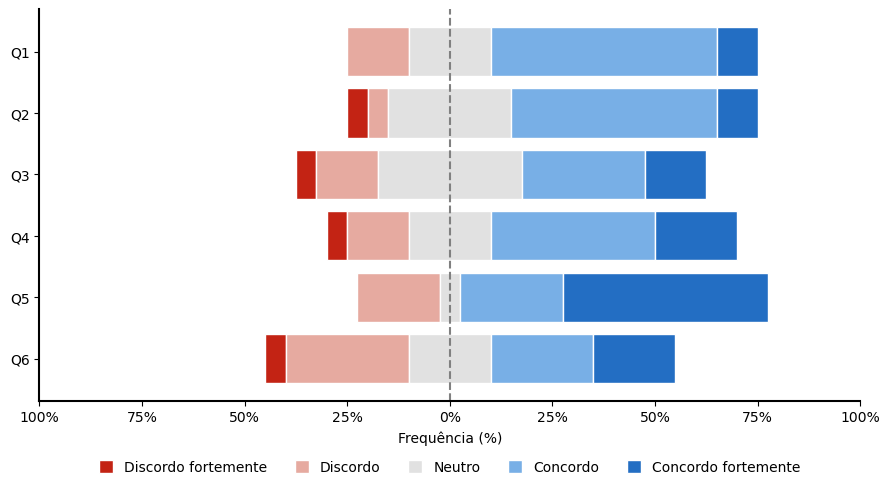

Sample 2


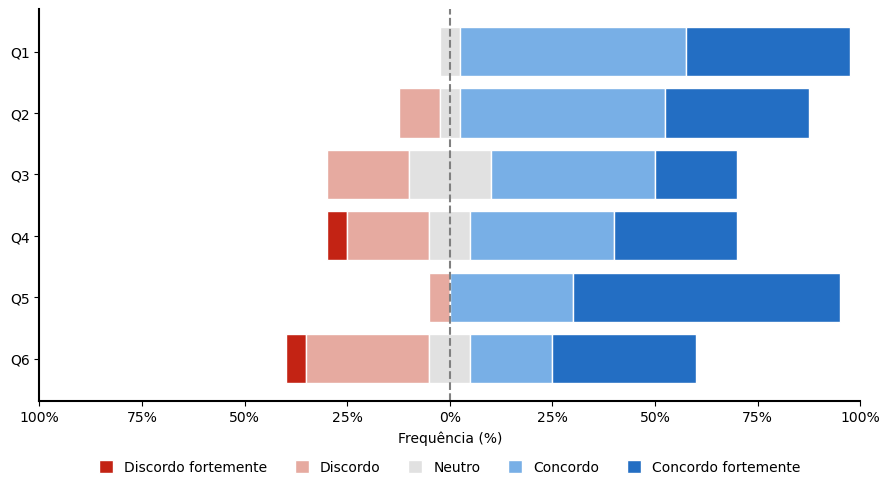

Sample 3


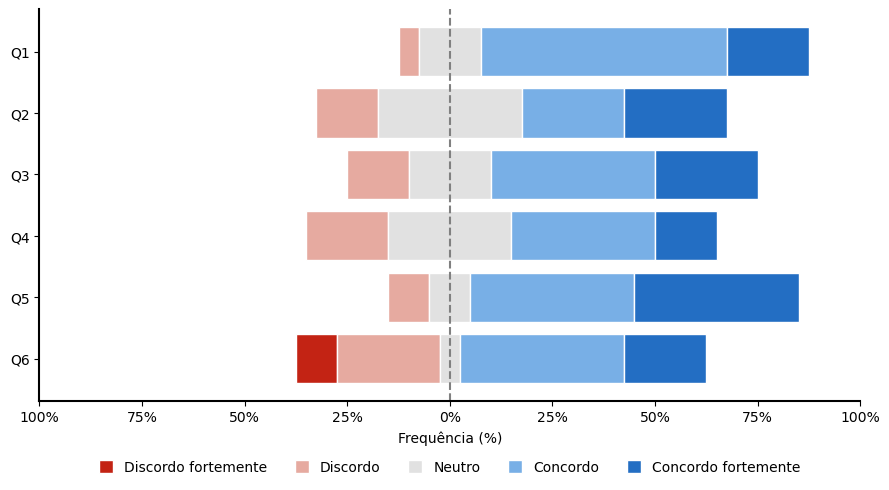

Sample 4


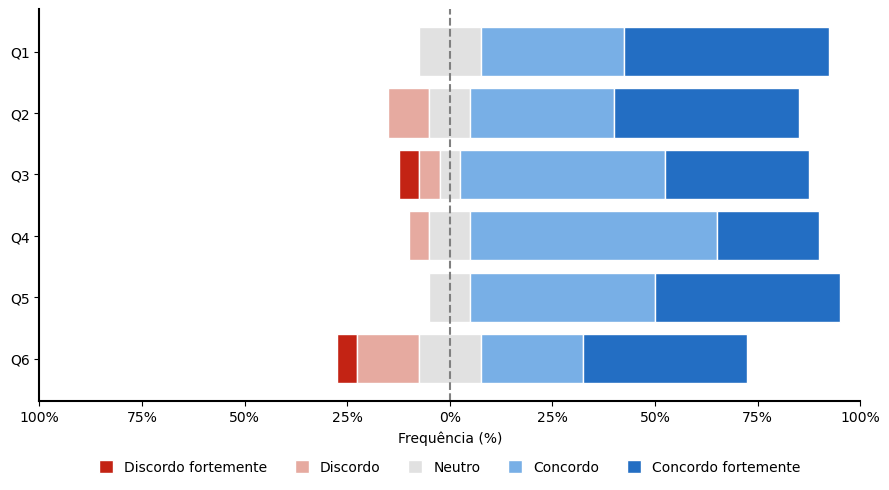

Sample 5


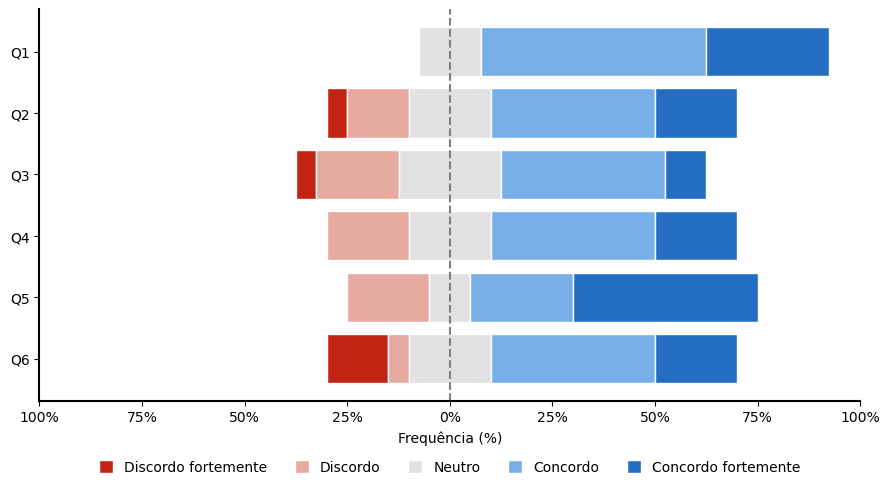

Sample 6


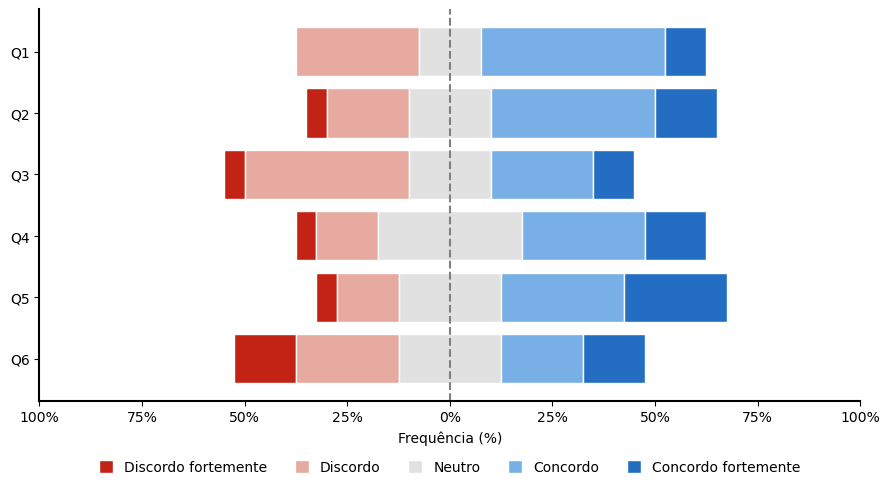

In [4]:
survey_data = preprocess_survey_data()

for i, sample_df in enumerate(survey_data):
    print(f'Sample {i+1}')
    plot_likert_diverging(sample_df, i+1)

### Extracting insights to use on results and discussion

In [5]:
category_map = {
    1: 'negative',
    2: 'negative',
    3: 'neutral',
    4: 'positive',
    5: 'positive'
}
def unify_and_categorize_survey_data(samples_dfs):
    unified_rows = []
    
    
    for sample_idx, df in enumerate(samples_dfs):
        df_temp = df.copy()
        
        df_temp['Sample'] = f'Amostra_{sample_idx + 1}'
        df_temp['Respondent'] = df_temp.index + 1 
        
        cols_to_map = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']
        for col in cols_to_map:
            if col in df_temp.columns:
                df_temp[col] = df_temp[col].map(category_map)
                
        unified_rows.append(df_temp)
        
    return pd.concat(unified_rows, ignore_index=True)

def calculate_avg_category_frequency(df_unified, questao, category):
    
    # Calcula a frequência (em %) de cada categoria para CADA amostra
    freq_per_sample = df_unified.groupby('Sample')[questao].value_counts(normalize=True).unstack(fill_value=0) * 100
    
    if category not in freq_per_sample.columns:
        return 0
        
    category_frequency = freq_per_sample[category]
    
    # A frequência média da categoria considerando todas as amostras
    avg = category_frequency.mean()
    
    
    print(f"\n--- Análise de Frequência: {questao} | Alvo: '{category}' ---")
    print("Frequência da categoria por amostra:")
    print(", ".join(category_frequency.round(1).astype(str) + '%'))
    print(f"\n(Frequência média de '{category}' entre todas as amostras): {avg:.2f}%\n")
    print("=" * 50)

df_unified = unify_and_categorize_survey_data(survey_data)

## Evaluating Q1 avg results

In [6]:
calculate_avg_category_frequency(df_unified, 'Q1', 'positive')
calculate_avg_category_frequency(df_unified, 'Q1', 'negative')
calculate_avg_category_frequency(df_unified, 'Q1', 'neutral')


--- Análise de Frequência: Q1 | Alvo: 'positive' ---
Frequência da categoria por amostra:
65.0%, 95.0%, 80.0%, 85.0%, 85.0%, 55.0%

(Frequência média de 'positive' entre todas as amostras): 77.50%


--- Análise de Frequência: Q1 | Alvo: 'negative' ---
Frequência da categoria por amostra:
15.0%, 0.0%, 5.0%, 0.0%, 0.0%, 30.0%

(Frequência média de 'negative' entre todas as amostras): 8.33%


--- Análise de Frequência: Q1 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
20.0%, 5.0%, 15.0%, 15.0%, 15.0%, 15.0%

(Frequência média de 'neutral' entre todas as amostras): 14.17%



## Evaluating Q2 avg results

In [7]:
calculate_avg_category_frequency(df_unified, 'Q2', 'positive')
calculate_avg_category_frequency(df_unified, 'Q2', 'negative')
calculate_avg_category_frequency(df_unified, 'Q2', 'neutral')


--- Análise de Frequência: Q2 | Alvo: 'positive' ---
Frequência da categoria por amostra:
60.0%, 85.0%, 50.0%, 80.0%, 60.0%, 55.0%

(Frequência média de 'positive' entre todas as amostras): 65.00%


--- Análise de Frequência: Q2 | Alvo: 'negative' ---
Frequência da categoria por amostra:
10.0%, 10.0%, 15.0%, 10.0%, 20.0%, 25.0%

(Frequência média de 'negative' entre todas as amostras): 15.00%


--- Análise de Frequência: Q2 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
30.0%, 5.0%, 35.0%, 10.0%, 20.0%, 20.0%

(Frequência média de 'neutral' entre todas as amostras): 20.00%



## Evaluating Q3 avg results

In [8]:
calculate_avg_category_frequency(df_unified, 'Q3', 'positive')
calculate_avg_category_frequency(df_unified, 'Q3', 'negative')
calculate_avg_category_frequency(df_unified, 'Q3', 'neutral')


--- Análise de Frequência: Q3 | Alvo: 'positive' ---
Frequência da categoria por amostra:
45.0%, 60.0%, 65.0%, 85.0%, 50.0%, 35.0%

(Frequência média de 'positive' entre todas as amostras): 56.67%


--- Análise de Frequência: Q3 | Alvo: 'negative' ---
Frequência da categoria por amostra:
20.0%, 20.0%, 15.0%, 10.0%, 25.0%, 45.0%

(Frequência média de 'negative' entre todas as amostras): 22.50%


--- Análise de Frequência: Q3 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
35.0%, 20.0%, 20.0%, 5.0%, 25.0%, 20.0%

(Frequência média de 'neutral' entre todas as amostras): 20.83%



## Evaluating Q4 avg results

In [9]:
calculate_avg_category_frequency(df_unified, 'Q4', 'positive')
calculate_avg_category_frequency(df_unified, 'Q4', 'negative')
calculate_avg_category_frequency(df_unified, 'Q4', 'neutral')


--- Análise de Frequência: Q4 | Alvo: 'positive' ---
Frequência da categoria por amostra:
60.0%, 65.0%, 50.0%, 85.0%, 60.0%, 45.0%

(Frequência média de 'positive' entre todas as amostras): 60.83%


--- Análise de Frequência: Q4 | Alvo: 'negative' ---
Frequência da categoria por amostra:
20.0%, 25.0%, 20.0%, 5.0%, 20.0%, 20.0%

(Frequência média de 'negative' entre todas as amostras): 18.33%


--- Análise de Frequência: Q4 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
20.0%, 10.0%, 30.0%, 10.0%, 20.0%, 35.0%

(Frequência média de 'neutral' entre todas as amostras): 20.83%



## Evaluating Q5 avg results

In [10]:
calculate_avg_category_frequency(df_unified, 'Q5', 'positive')
calculate_avg_category_frequency(df_unified, 'Q5', 'negative')
calculate_avg_category_frequency(df_unified, 'Q5', 'neutral')


--- Análise de Frequência: Q5 | Alvo: 'positive' ---
Frequência da categoria por amostra:
75.0%, 95.0%, 80.0%, 90.0%, 70.0%, 55.0%

(Frequência média de 'positive' entre todas as amostras): 77.50%


--- Análise de Frequência: Q5 | Alvo: 'negative' ---
Frequência da categoria por amostra:
20.0%, 5.0%, 10.0%, 0.0%, 20.0%, 20.0%

(Frequência média de 'negative' entre todas as amostras): 12.50%


--- Análise de Frequência: Q5 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
5.0%, 0.0%, 10.0%, 10.0%, 10.0%, 25.0%

(Frequência média de 'neutral' entre todas as amostras): 10.00%



## Evaluating Q6 avg results

In [11]:
calculate_avg_category_frequency(df_unified, 'Q6', 'positive')
calculate_avg_category_frequency(df_unified, 'Q6', 'negative')
calculate_avg_category_frequency(df_unified, 'Q6', 'neutral')


--- Análise de Frequência: Q6 | Alvo: 'positive' ---
Frequência da categoria por amostra:
45.0%, 55.0%, 60.0%, 65.0%, 60.0%, 35.0%

(Frequência média de 'positive' entre todas as amostras): 53.33%


--- Análise de Frequência: Q6 | Alvo: 'negative' ---
Frequência da categoria por amostra:
35.0%, 35.0%, 35.0%, 20.0%, 20.0%, 40.0%

(Frequência média de 'negative' entre todas as amostras): 30.83%


--- Análise de Frequência: Q6 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
20.0%, 10.0%, 5.0%, 15.0%, 20.0%, 25.0%

(Frequência média de 'neutral' entre todas as amostras): 15.83%



In [12]:
col_background = "Which better describes your professional background?"
def process_and_unify_with_background():
    df_raw = pd.read_csv(DATA_PATH)
    
    # Captura a coluna de perfil profissional (ajuste o nome se necessário)
    backgrounds = df_raw[col_background]
    
    df_questions = df_raw.iloc[:, 5:-1].copy()
    df_questions = df_questions.replace(response_map)
    
    num_questions = len(map_questions)
    num_cols = df_questions.shape[1]
    unified_rows = []
    
    # Itera pelos blocos de questões (cada bloco é uma amostra)
    for i in range(0, num_cols, num_questions):
        sample_idx = (i // num_questions) + 1
        chunk = df_questions.iloc[:, i:i+num_questions].copy()
        
        # Limpa nomes das colunas e aplica o mapeamento de questões
        chunk.columns = chunk.columns.str.replace(r'\.\d+$', '', regex=True)
        chunk = chunk.rename(columns=map_questions)
        
        # Adiciona metadados
        chunk['Sample'] = f'Amostra_{sample_idx}'
        chunk['Professional_Background'] = backgrounds.values
        chunk['Respondent_ID'] = chunk.index
        
        # Mapeia as notas para as 3 categorias definidas na sua metodologia
        for col in map_questions.values():
            chunk[col] = chunk[col].map(category_map)
            
        unified_rows.append(chunk)
    
    return pd.concat(unified_rows, ignore_index=True)


df_final = process_and_unify_with_background()
fe_option = "Frontend / UI Engineer"
designer_option = "UI Designer / UX researcher"

designer_df = df_final[df_final['Professional_Background'] == designer_option].copy()
fe_df = df_final[df_final['Professional_Background'] == fe_option].copy()

print("\n--- Métricas da Q6: Frontend Developers ---")
calculate_avg_category_frequency(fe_df, 'Q6', 'positive')
calculate_avg_category_frequency(fe_df, 'Q6', 'negative')
calculate_avg_category_frequency(fe_df, 'Q6', 'neutral')

print("--- Métricas da Q6: UI/UX Designers ---")
calculate_avg_category_frequency(designer_df, 'Q6', 'positive')
calculate_avg_category_frequency(designer_df, 'Q6', 'negative')
calculate_avg_category_frequency(designer_df, 'Q6', 'neutral')



--- Métricas da Q6: Frontend Developers ---

--- Análise de Frequência: Q6 | Alvo: 'positive' ---
Frequência da categoria por amostra:
42.9%, 57.1%, 71.4%, 85.7%, 64.3%, 50.0%

(Frequência média de 'positive' entre todas as amostras): 61.90%


--- Análise de Frequência: Q6 | Alvo: 'negative' ---
Frequência da categoria por amostra:
28.6%, 35.7%, 28.6%, 7.1%, 14.3%, 28.6%

(Frequência média de 'negative' entre todas as amostras): 23.81%


--- Análise de Frequência: Q6 | Alvo: 'neutral' ---
Frequência da categoria por amostra:
28.6%, 7.1%, 0.0%, 7.1%, 21.4%, 21.4%

(Frequência média de 'neutral' entre todas as amostras): 14.29%

--- Métricas da Q6: UI/UX Designers ---

--- Análise de Frequência: Q6 | Alvo: 'positive' ---
Frequência da categoria por amostra:
50.0%, 50.0%, 33.3%, 16.7%, 50.0%, 0.0%

(Frequência média de 'positive' entre todas as amostras): 33.33%


--- Análise de Frequência: Q6 | Alvo: 'negative' ---
Frequência da categoria por amostra:
50.0%, 33.3%, 50.0%, 50.0%, 33.3%, 

/tmp/ipykernel_2496007/1383952332.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_questions = df_questions.replace(response_map)
